<a href="https://colab.research.google.com/github/AdrianP428/DSRP_Project_MMF/blob/main/DSRP_Project_AP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay

In [72]:
df = pd.read_csv('loans_full_schema.csv')

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

In [74]:
df.value_counts()

emp_title                 emp_length  state  homeownership  annual_income  verified_income  debt_to_income  annual_income_joint  verification_income_joint  debt_to_income_joint  delinq_2y  months_since_last_delinq  earliest_credit_line  inquiries_last_12m  total_credit_lines  open_credit_lines  total_credit_limit  total_credit_utilized  num_collections_last_12m  num_historical_failed_to_pay  months_since_90d_late  current_accounts_delinq  total_collection_amount_ever  current_installment_accounts  accounts_opened_24m  months_since_last_credit_inquiry  num_satisfactory_accounts  num_accounts_120d_past_due  num_accounts_30d_past_due  num_active_debit_accounts  total_debit_limit  num_total_cc_accounts  num_open_cc_accounts  num_cc_carrying_balance  num_mort_accounts  account_never_delinq_percent  tax_liens  public_record_bankrupt  loan_purpose        application_type  loan_amount  term  interest_rate  installment  grade  sub_grade  issue_month  loan_status  initial_listing_status  disbursement_method  balance   paid_total  paid_principal  paid_interest  paid_late_fees
 lead hydraulic mechanic  10.0        CO     RENT           40600.0        Source Verified  32.04           100800.0             Source Verified            32.40                 3          20.0                      2005                  7                   13                  5                  80161               64089                  0                         0                             20.0                   0                        0                             2                             2                    3.0                               5                          0.0                         0                          2                          12300              5                      3                     3                        3                  75.0                          0          0                       debt_consolidation  joint             11400        60    18.45          292.29       D      D2         Mar-2018     Current      whole                   Cash                 11043.53  853.50      356.47          497.03         0.0               1
1st grade teacher         2.0         TN     MORTGAGE       45000.0        Source Verified  28.48           80000.0              Not Verified               25.48                 0          32.0                      2003                  2                   27                  19                 177925              53762                  0                         0                             41.0                   0                        0                             2                             2                    8.0                               19                         0.0                         0                          5                          8900               20                     16                    11                       1                  92.6                          0          0                       car                 joint             2000         36    13.59          67.96        C      C2         Jan-2018     Current      fractional              Cash                 1768.26   336.78      231.74          105.04         0.0               1
account manager           7.0         NC     MORTGAGE       175000.0       Verified         18.09           210000.0             Verified                   17.62                 1          12.0                      2001                  10                  19                  10                 149097              117678                 0                         0                             53.0                   0                        0                             4                             6                    0.0                               10                         0.0                         0                          2                          3100               11                     6                     5            

In [75]:
df.head()
print(df['term'])

0       60
1       36
2       36
3       36
4       36
        ..
9995    36
9996    36
9997    36
9998    36
9999    36
Name: term, Length: 10000, dtype: int64


In [76]:
df = df.drop(columns = ['issue_month'])

In [77]:
df['has_prior_delinq'] = df['months_since_last_delinq'].notna().astype(int)
df['months_since_90d_late'] = df['months_since_last_delinq'].fillna(999)

df['has_90d_late'] = df['months_since_90d_late'].notna().astype(int)
df['months_since_90d_late'].fillna(999)

df['has_recent_inquiry'] = df['months_since_last_credit_inquiry'].notna().astype(int)
df['months_since_last_credit_inquiry'] = df['months_since_last_credit_inquiry'].fillna(999)

df['emp_length_missing'] = df['emp_length'].isna().astype(int)
df['emp_length'] = df['emp_length'].fillna(0)

In [78]:
df['dti_effective'] = df['debt_to_income_joint'].fillna(df['debt_to_income'])
df['dti_effective'] = df['dti_effective'].fillna(df['dti_effective'].median())


In [79]:
grade = {"A1": 1, 'A2': 2, 'A3': 3, 'A4' : 4, 'A5' : 5, 'B1': 6, 'B2' : 7, 'B3' : 8, 'B4' : 9, 'B5' : 10, 'C1' : 11, 'C2' : 12, 'C3' : 13, 'C4' : 14, 'C5' : 15, 'D1' : 16, 'D2' : 17, 'D3' : 18, 'D4' : 19, 'D5' : 20, 'E1' : 21, 'E2' : 22, 'E3': 23, 'E4' : 24, 'E5' : 25, 'F1' : 26, 'F2': 27, 'F3' : 28, 'F4' : 29, 'F5': 30, 'G1': 31, 'G2' : 32, 'G3': 33, 'G4': 34, 'G5': 35}
df['grade_num'] = df['sub_grade'].map(grade)
df['grade_letter'] = df['sub_grade'].str[0]

In [80]:

df = df[df['dti_effective'] <= 100]
df = df[df['annual_income'] >= 5000]


In [81]:
df['loan_to_income'] = df['loan_amount'] / df['annual_income']
df['credit_utilized'] = np.where(df['total_credit_limit'] > 0, df['total_credit_utilized'] / df['total_credit_limit'], np.nan)
df['credit_age_years'] = 2018 - df['earliest_credit_line']

In [82]:
cap = df['annual_income'].quantile(0.99)
df['annual_income'] = df['annual_income'].clip(upper=cap)
cap = df['dti_effective'].quantile(0.99)
df['dti_effective'] = df['dti_effective'].clip(upper=cap)
cap = df['credit_utilized'].quantile(0.99)
df['credit_utilized'] = df['credit_utilized'].clip(upper=cap)
cap = df['loan_to_income'].quantile(0.99)
df['loan_to_income'] = df['loan_to_income'].clip(upper=cap)
cap = df['loan_amount'].quantile(0.99)
df['loan_amount'] = df['loan_amount'].clip(upper=cap)

In [83]:
print(df['annual_income'].sort_values())
print(df['dti_effective'].sort_values())
print(df['credit_utilized'].sort_values())
print(df['loan_to_income'].sort_values())
print(df['loan_amount'].sort_values())

6799      5000.0
7231      5000.0
2759      5208.0
2875      5235.0
8688      5500.0
          ...   
5271    300000.0
9001    300000.0
1243    300000.0
7063    300000.0
5855    300000.0
Name: annual_income, Length: 9970, dtype: float64
35       0.00
7498     0.00
4931     0.00
3933     0.00
4022     0.00
        ...  
729     37.66
9465    37.66
9516    37.66
613     37.66
9973    37.66
Name: dti_effective, Length: 9970, dtype: float64
7481    0.000000
7498    0.000000
1118    0.000000
4559    0.000000
4931    0.000000
          ...   
9586    1.050814
9596    1.050814
9988    1.050814
4022         NaN
9056         NaN
Name: credit_utilized, Length: 9970, dtype: float64
8243    0.001282
3923    0.007500
4414    0.007692
2779    0.007910
9348    0.007937
          ...   
7384    0.964234
1168    0.964234
9491    0.964234
8649    0.964234
5866    0.964234
Name: loan_to_income, Length: 9970, dtype: float64
2857     1000
8578     1000
2475     1000
3906     1000
1823     1000
        ... 

In [84]:
df = df.dropna(subset=['credit_utilized'])
df['credit_utilized'].sort_values()

,credit_utilized
7481,0.000000
7498,0.000000
1118,0.000000
4559,0.000000
4931,0.000000
...,...
4876,1.050814
9560,1.050814
9586,1.050814
9596,1.050814


In [85]:
df['log_income'] = np.log1p(df['annual_income'])

In [86]:
print(df['dti_effective'].corr(df['grade_num']))

0.2219296431052528


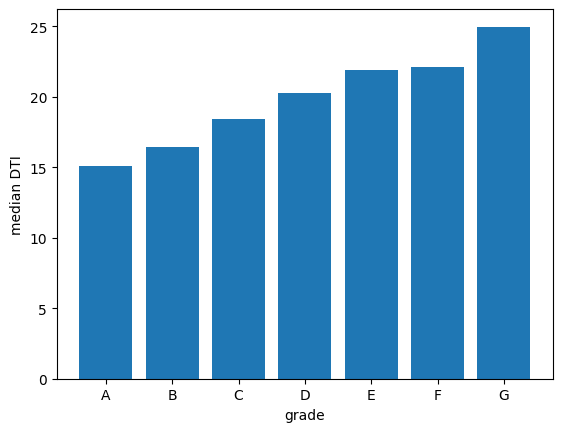

In [87]:
g = df.groupby('grade_letter')['dti_effective'].median()
x = g.index
y = g.values

plt.bar(x, y)
plt.xlabel('grade')
plt.ylabel('median DTI')
plt.show()

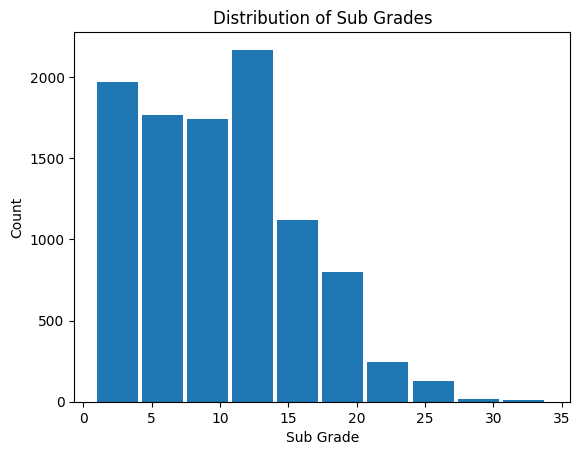

In [88]:
df['grade_num'].plot(kind = 'hist', width = 3)
plt.title("Distribution of Sub Grades")
plt.xlabel('Sub Grade')
plt.ylabel('Count')

plt.show()

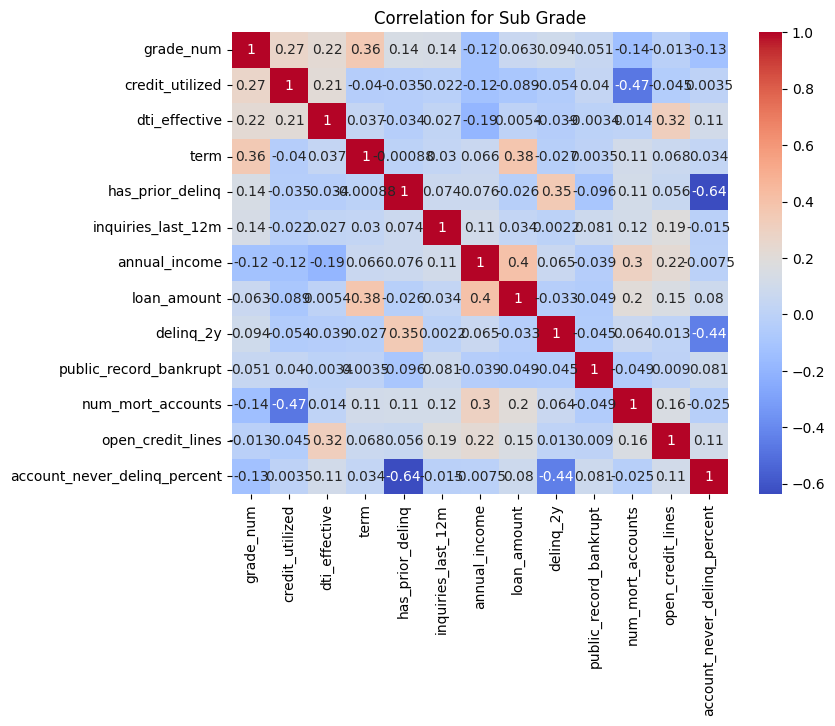

In [89]:
col = ['grade_num', 'credit_utilized', 'dti_effective', 'term',
        'has_prior_delinq', 'inquiries_last_12m', 'annual_income',
        'loan_amount', 'delinq_2y', 'public_record_bankrupt',
        'num_mort_accounts', 'open_credit_lines', 'account_never_delinq_percent']

correlations = df[col].corr()
plt.figure(figsize = (8,6))
sns.heatmap(correlations, annot=True, cmap = 'coolwarm')
plt.title('Correlation for Sub Grade')
plt.show()

/tmp/ipykernel_2421/1809799698.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gr = df.groupby('group_age')['has_prior_delinq'].mean() * 100


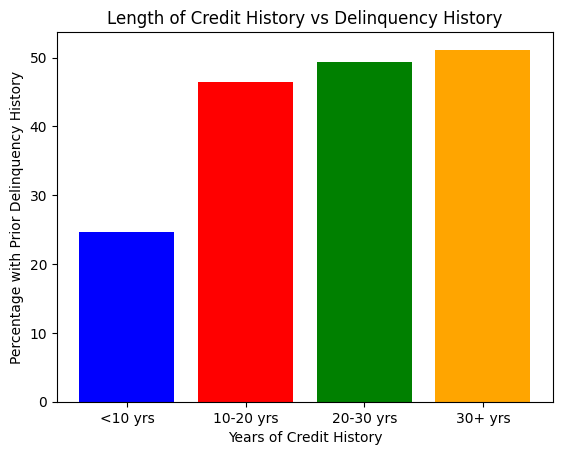

In [90]:
df['group_age'] = pd.cut(df['credit_age_years'], bins = [0,10,20,30,400])
gr = df.groupby('group_age')['has_prior_delinq'].mean() * 100
label = ['<10 yrs', '10-20 yrs', '20-30 yrs', '30+ yrs']
plt.bar(label, gr.values, color = ['blue', 'red', 'green', 'orange'])
plt.title('Length of Credit History vs Delinquency History')
plt.xlabel('Years of Credit History')
plt.ylabel('Percentage with Prior Delinquency History')
plt.show()

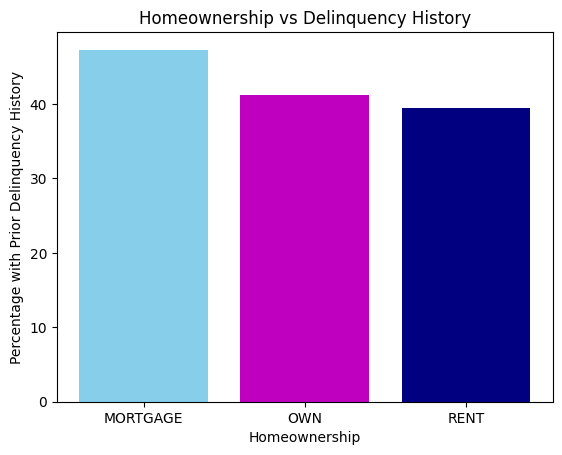

In [91]:
rates = df.groupby('homeownership')['has_prior_delinq'].mean() * 100
plt.bar(rates.index, rates.values, color = ['skyblue', 'm', 'navy'])
plt.xlabel('Homeownership')
plt.ylabel('Percentage with Prior Delinquency History')
plt.title('Homeownership vs Delinquency History')
plt.show()

/tmp/ipykernel_2421/2640274615.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gro = df.groupby('dti_group')['has_prior_delinq'].mean() * 100


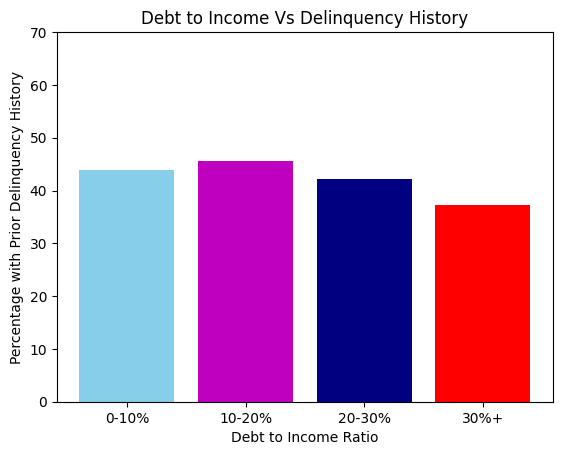

In [92]:
df['dti_group'] = pd.cut(df['dti_effective'], bins = [0,10,20,30,400])
gro = df.groupby('dti_group')['has_prior_delinq'].mean() * 100
label = ['0-10%', '10-20%', '20-30%', '30%+']
plt.bar(label, gro.values, color = ['skyblue', 'm', 'navy', 'red'])
plt.title('Debt to Income Vs Delinquency History')
plt.xlabel('Debt to Income Ratio')
plt.ylabel('Percentage with Prior Delinquency History')
plt.ylim(0,70)
plt.show()

In [93]:
delinq = df[df['has_prior_delinq'] == 1]['total_credit_lines']
clean = df[df['has_prior_delinq'] == 0]['total_credit_lines']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # of credit acc
#H1: Delinq and Non Delinq dont have same avg # of credit acc XXX

15.108294367141053
5.232478712683523e-51


In [94]:
delinq = df[df['has_prior_delinq'] == 1]['credit_age_years']
clean = df[df['has_prior_delinq'] == 0]['credit_age_years']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # of credit years
#H1: Delinq and Non Delinq dont have same avg # of credit years XXX

13.779298396972733
8.371960038115246e-43


In [95]:
delinq = df[df['has_prior_delinq'] == 1]['num_mort_accounts']
clean = df[df['has_prior_delinq'] == 0]['num_mort_accounts']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # of mortgage accounts
#H1: Delinq and Non Delinq dont have same avg # of mortgage accounts XXX

11.28855826962484
2.2527651063170915e-29


In [96]:
delinq = df[df['has_prior_delinq'] == 1]['public_record_bankrupt']
clean = df[df['has_prior_delinq'] == 0]['public_record_bankrupt']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # of bankruptcies
#H1: Delinq and Non Delinq dont have same avg # bankruptcies XXX

-9.612884961779992
8.768258498318319e-22


In [97]:
delinq = df[df['has_prior_delinq'] == 1]['loan_to_income']
clean = df[df['has_prior_delinq'] == 0]['loan_to_income']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # loan to income
#H1: Delinq and Non Delinq dont have same avg # loan to income XXX

-9.589391244432145
1.0990282618971473e-21


In [98]:
delinq = df[df['has_prior_delinq'] == 1]['log_income']
clean = df[df['has_prior_delinq'] == 0]['log_income']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # log income
#H1: Delinq and Non Delinq dont have same avg # log income XXX

9.45391063309687
4.001215771046896e-21


In [99]:
delinq = df[df['has_prior_delinq'] == 1]['inquiries_last_12m']
clean = df[df['has_prior_delinq'] == 0]['inquiries_last_12m']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # of times a borrower applied for credit in 12 Months
#H1: Delinq and Non Delinq dont have same avg # of times a borrower applied for credit in 12 Months XXX

7.413405177540312
1.3311219842448933e-13


In [100]:
delinq = df[df['has_prior_delinq'] == 1]['accounts_opened_24m']
clean = df[df['has_prior_delinq'] == 0]['accounts_opened_24m']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # of times a borrower opened acc in 24 Months
#H1: Delinq and Non Delinq dont have same avg # of times a borrower opened acc in 24 Months XXX

5.956883538929268
2.657901462606989e-09


In [101]:
delinq = df[df['has_prior_delinq'] == 1]['open_credit_lines']
clean = df[df['has_prior_delinq'] == 0]['open_credit_lines']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # of open credit lines
#H1: Delinq and Non Delinq dont have same avg # of open credit lines XXX

5.583356227525594
2.4210349510570773e-08


In [102]:
delinq = df[df['has_prior_delinq'] == 1]['num_active_debit_accounts']
clean = df[df['has_prior_delinq'] == 0]['num_active_debit_accounts']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # of active debit acc
#H1: Delinq and Non Delinq dont have same avg # of active debit acc XXX LL

-3.5054890432615533
0.0004577727434030686


In [103]:
delinq = df[df['has_prior_delinq'] == 1]['emp_length']
clean = df[df['has_prior_delinq'] == 0]['emp_length']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # employment length
#H1: Delinq and Non Delinq dont have same avg # employment length XXX LL

3.524883411148579
0.00042557039300653493


In [104]:
delinq = df[df['has_prior_delinq'] == 1]['credit_utilized']
clean = df[df['has_prior_delinq'] == 0]['credit_utilized']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # of credit utilization
#H1: Delinq and Non Delinq dont have same avg # credit utilization XXX LL

-3.514017471013377
0.0004433417263095091


In [105]:
delinq = df[df['has_prior_delinq'] == 1]['dti_effective']
clean = df[df['has_prior_delinq'] == 0]['dti_effective']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # debt to income
#H1: Delinq and Non Delinq dont have same avg # debt to income XXX LL

-3.429839115819996
0.0006063865149136713


In [106]:
delinq = df[df['has_prior_delinq'] == 1]['loan_amount']
clean = df[df['has_prior_delinq'] == 0]['loan_amount']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # loan amount
#H1: Delinq and Non Delinq dont have same avg # loan amount XXX LL

-2.6007562000207893
0.009315590756256948


In [107]:
delinq = df[df['has_prior_delinq'] == 1]['num_cc_carrying_balance']
clean = df[df['has_prior_delinq'] == 0]['num_cc_carrying_balance']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # of credit cards not payed off
#H1: Delinq and Non Delinq dont have same avg # of credit cards not payed off XXX LL

1.9785448569448374
0.04789476261667506


In [108]:
delinq = df[df['has_prior_delinq'] == 1]['tax_liens']
clean = df[df['has_prior_delinq'] == 0]['tax_liens']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # of tax liens
#H1: Delinq and Non Delinq dont have same avg # of tax liens XXX LL

2.0371112748186806
0.04166525976005123


In [109]:
delinq = df[df['has_prior_delinq'] == 1]['emp_length_missing']
clean = df[df['has_prior_delinq'] == 0]['emp_length_missing']

t_stat, p_val = stats.ttest_ind(delinq, clean )

print(t_stat)
print(p_val)

#H0: Delinq and Non Delinq have same avg # missing employment time records XXX
#H1: Delinq and Non Delinq dont have same avg # missing employment time records

-0.18861795243540325
0.8503961019159295


In [110]:
table = pd.crosstab(df['homeownership'], df['has_prior_delinq'])
result = stats.chi2_contingency(table)
chi2_stat = result.statistic
p_val = result.pvalue

#H0: Delinq rate is same across all homeownership groups
#H1: Delinq rate differs by group XX

print(chi2_stat)
print(p_val)

56.515555205733
5.343220740348591e-13


In [111]:
table = pd.crosstab(df['loan_purpose'], df['has_prior_delinq'])
result = stats.chi2_contingency(table)
chi2_stat = result.statistic
p_val = result.pvalue

#H0: Delinq rate is same across all loan purpose groups
#H1: Delinq rate differs by loan purpose groups XX

print(chi2_stat)
print(p_val)

29.647096119283724
0.0017997810711735261


In [112]:
X = df[['dti_effective', 'credit_utilized', 'log_income', 'loan_to_income',
                  'inquiries_last_12m', 'credit_age_years', 'loan_amount',
                  'open_credit_lines', 'total_credit_lines', 'num_mort_accounts',
                  'accounts_opened_24m', 'num_cc_carrying_balance',
                  'num_active_debit_accounts', 'public_record_bankrupt',
                  'tax_liens', 'emp_length', 'emp_length_missing']]
y = df['has_prior_delinq']


X = sm.add_constant(X)

logit_mod = sm.Logit(y, X)
logit_res = logit_mod.fit()

print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.646229
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:       has_prior_delinq   No. Observations:                 9968
Model:                          Logit   Df Residuals:                     9950
Method:                           MLE   Df Model:                           17
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                 0.05589
Time:                        16:52:34   Log-Likelihood:                -6441.6
converged:                       True   LL-Null:                       -6823.0
Covariance Type:            nonrobust   LLR p-value:                3.993e-151
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -3.1349      0.908     -3.451      0.001      -4.

In [113]:
predictors = ['total_credit_lines','credit_age_years', 'public_record_bankrupt', 'num_active_debit_accounts', 'num_cc_carrying_balance', 'open_credit_lines', 'loan_amount', 'dti_effective', 'log_income', 'inquiries_last_12m', 'tax_liens', 'num_mort_accounts']

In [114]:
X_data = df[predictors]
y_data = df['has_prior_delinq']

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42, stratify = y_data)

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter = 1000, class_weight= 'balanced', random_state = 42))

logreg.fit(X_train, y_train)


auc = (cross_val_score(logreg, X_data, y_data, cv=5, scoring = 'roc_auc').mean())
print('Multiple Tests:', auc)

Multiple Tests: 0.6588763136280249


Forest AUC: 0.6721429270687607


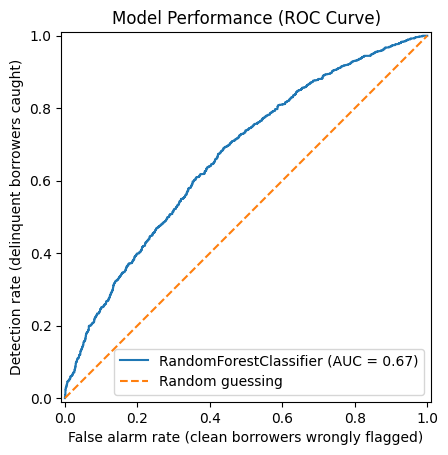

In [118]:
predict = ['total_credit_lines','credit_age_years', 'public_record_bankrupt', 'num_active_debit_accounts', 'num_cc_carrying_balance', 'open_credit_lines', 'loan_amount', 'dti_effective', 'log_income', 'inquiries_last_12m', 'tax_liens', 'num_mort_accounts']

X_val = df[predict]
y_val = df['has_prior_delinq']

X_train, X_test, y_train, y_test = train_test_split(X_val, y_val, test_size = 0.25, random_state = 42, stratify= y_val)
forest = RandomForestClassifier (n_estimators=300, min_samples_leaf = 15, class_weight = 'balanced', random_state = 108)

forest.fit(X_train, y_train)
RocCurveDisplay.from_estimator(forest, X_test, y_test)
auc = cross_val_score(forest, X_val, y_val, cv = 5, scoring = 'roc_auc').mean()

print("Forest AUC:", auc)

plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.title('Model Performance (ROC Curve)')
plt.xlabel('False alarm rate (clean borrowers wrongly flagged)')
plt.ylabel('Detection rate (delinquent borrowers caught)')
plt.legend()
plt.show()

In [116]:
importances = pd.Series(forest.feature_importances_, index = predict)
print(importances.sort_values(ascending=False))

credit_age_years             0.174205
total_credit_lines           0.158562
dti_effective                0.133021
log_income                   0.105451
loan_amount                  0.104054
open_credit_lines            0.068045
num_active_debit_accounts    0.056637
inquiries_last_12m           0.053625
num_mort_accounts            0.052816
num_cc_carrying_balance      0.049743
public_record_bankrupt       0.042557
tax_liens                    0.001285
dtype: float64


/tmp/ipykernel_2421/1825480150.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gro = df.groupby('inc_group')['has_prior_delinq'].mean() * 100


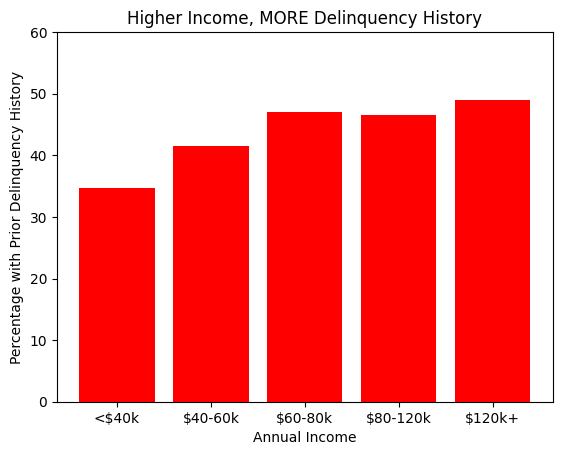

In [117]:
df['inc_group'] = pd.cut(df['annual_income'], bins = [0,40000,60000,80000,120000,10000000000])
gro = df.groupby('inc_group')['has_prior_delinq'].mean() * 100
label = ['<$40k', '$40-60k', '$60-80k', '$80-120k', '$120k+']
plt.bar(label, gro.values, color = ['red'])
plt.title('Higher Income, MORE Delinquency History')
plt.xlabel('Annual Income')
plt.ylabel('Percentage with Prior Delinquency History')
plt.ylim(0,60)
plt.show()